# Loading Students Academic Performance Dataset from Kaggle

In [6]:
# Cell 1: Verify packages are installed (runs in 1 second)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn import preprocessing
import kaggle

print("✓ All packages imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("Ready to proceed with data analysis!")

✓ All packages imported successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6
Ready to proceed with data analysis!


In [8]:
# Cell 2: Import all necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Plotly version: {plotly.__version__}")

✓ All libraries imported successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6
Seaborn version: 0.13.2
Plotly version: 6.7.0


In [9]:
# Cell 3: Authenticate with Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi

# Create .kaggle directory if it doesn't exist
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Authenticate
api = KaggleApi()
api.authenticate()

print("✓ Kaggle authentication successful!")
print(f"Kaggle API version: {kaggle.__version__ if 'kaggle' in dir() else 'Available'}")

✓ Kaggle authentication successful!
Kaggle API version: 2.1.2


In [10]:
# Cell 4: Download the dataset
dataset_name = "itszubi/students-academic-performance-dataset"
download_path = "data"

# Create data directory if it doesn't exist
os.makedirs(download_path, exist_ok=True)

# Download the dataset
print(f"Downloading {dataset_name}...")
api.dataset_download_files(dataset_name, path=download_path, unzip=True)
print(f"✓ Dataset downloaded successfully to '{download_path}/' folder!")

# List downloaded files
print("\nFiles in data folder:")
for file in os.listdir(download_path):
    file_size = os.path.getsize(os.path.join(download_path, file)) / 1024  # Size in KB
    print(f"  - {file} ({file_size:.2f} KB)")

Dataset URL: https://www.kaggle.com/datasets/itszubi/students-academic-performance-dataset
✓ Dataset downloaded successfully to 'data/' folder!

Files in data folder:
  - StudentPerformanceFactors.csv (626.90 KB)


In [11]:
# Cell 5: Load the dataset
import pandas as pd

# Load the CSV file
df = pd.read_csv('data/StudentPerformanceFactors.csv')

print("✓ Dataset loaded successfully!")
print(f"\n{'='*50}")
print("DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n{'='*50}")
print("COLUMN NAMES")
print(f"{'='*50}")
print(df.columns.tolist())
print(f"\n{'='*50}")
print("FIRST 5 ROWS")
print(f"{'='*50}")
print(df.head())
print(f"\n{'='*50}")
print("DATA TYPES")
print(f"{'='*50}")
print(df.dtypes)
print(f"\n{'='*50}")
print("MISSING VALUES")
print(f"{'='*50}")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found!")
print(f"\n{'='*50}")
print("BASIC STATISTICS (Numeric Columns)")
print(f"{'='*50}")
print(df.describe())

✓ Dataset loaded successfully!

DATASET OVERVIEW
Shape: 6607 rows × 20 columns

COLUMN NAMES
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

FIRST 5 ROWS
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Mot

In [12]:
# Cell 6: Handle missing values
print("=== HANDLING MISSING VALUES ===\n")
print(f"Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(f"\nMissing percentage:")
print(missing_percentage[missing_percentage > 0])

# Fill missing values with mode (most frequent value) for categorical columns
categorical_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)
    print(f"\n✓ Filled {col} with mode: '{mode_value}'")

print(f"\n{'='*50}")
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"{'='*50}")

=== HANDLING MISSING VALUES ===

Missing values before cleaning:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Total missing values: 235

Missing percentage:
Teacher_Quality             1.180566
Parental_Education_Level    1.362192
Distance_from_Home          1.014076
dtype: float64

✓ Filled Teacher_Quality with mode: 'Medium'

✓ Filled Parental_Education_Level with mode: 'High School'

✓ Filled Distance_from_Home with mode: 'Near'

Missing values after cleaning: 235


In [13]:
# Cell 6: Handle missing values correctly
print("=== HANDLING MISSING VALUES ===\n")
print(f"Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(f"\nMissing percentage:")
print(missing_percentage[missing_percentage > 0])

# Fill missing values with mode (most frequent value) for categorical columns
categorical_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)  # Fixed: reassign to column
    print(f"\n✓ Filled {col} with mode: '{mode_value}'")

print(f"\n{'='*50}")
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"{'='*50}")

# Verify no missing values remain
if df.isnull().sum().sum() == 0:
    print("\n✅ SUCCESS: All missing values have been handled!")
else:
    print(f"\n⚠️ Warning: Still have {df.isnull().sum().sum()} missing values")

=== HANDLING MISSING VALUES ===

Missing values before cleaning:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Total missing values: 235

Missing percentage:
Teacher_Quality             1.180566
Parental_Education_Level    1.362192
Distance_from_Home          1.014076
dtype: float64

✓ Filled Teacher_Quality with mode: 'Medium'

✓ Filled Parental_Education_Level with mode: 'High School'

✓ Filled Distance_from_Home with mode: 'Near'

Missing values after cleaning: 0

✅ SUCCESS: All missing values have been handled!


In [14]:
# Cell 7: Remove duplicates and fix data types
print("=== REMOVING DUPLICATES ===\n")
initial_rows = len(df)
df = df.drop_duplicates()
removed_rows = initial_rows - len(df)
print(f"Initial rows: {initial_rows}")
print(f"Rows after removing duplicates: {len(df)}")
print(f"Removed {removed_rows} duplicate rows ({removed_rows/initial_rows*100:.2f}%)")

print(f"\n{'='*50}")
print("=== FIXING DATA TYPES ===\n")

# Standardize string columns - strip whitespace and convert to title case
string_columns = df.select_dtypes(include=['object']).columns
print(f"Found {len(string_columns)} categorical columns to standardize:\n{string_columns.tolist()}\n")

for col in string_columns:
    # Strip whitespace and convert to title case
    df[col] = df[col].str.strip().str.title()
    # Convert to category type for memory efficiency
    df[col] = df[col].astype('category')
    print(f"✓ Standardized and converted '{col}' to category type")

print(f"\n{'='*50}")
print("UPDATED DATA TYPES:")
print(f"{'='*50}")
print(df.dtypes)

print(f"\n{'='*50}")
print("MEMORY USAGE:")
print(f"{'='*50}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== REMOVING DUPLICATES ===

Initial rows: 6607
Rows after removing duplicates: 6607
Removed 0 duplicate rows (0.00%)

=== FIXING DATA TYPES ===

Found 13 categorical columns to standardize:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

✓ Standardized and converted 'Parental_Involvement' to category type
✓ Standardized and converted 'Access_to_Resources' to category type
✓ Standardized and converted 'Extracurricular_Activities' to category type
✓ Standardized and converted 'Motivation_Level' to category type
✓ Standardized and converted 'Internet_Access' to category type
✓ Standardized and converted 'Family_Income' to category type
✓ Standardized and converted 'Teacher_Quality' to category type
✓ Standardized and converted 'School_Type' to category type
✓ Standard

In [15]:
# Cell 8: Handle outliers and invalid values
print("=== HANDLING OUTLIERS & INVALID VALUES ===\n")

# Check for Exam_Score > 100
invalid_scores = df[df['Exam_Score'] > 100]
if len(invalid_scores) > 0:
    print(f"⚠️ Found {len(invalid_scores)} rows with Exam_Score > 100")
    print(f"Values: {invalid_scores['Exam_Score'].tolist()}")
    # Cap at 100
    df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100
    print("✓ Capped Exam_Score at 100")
else:
    print("✓ No invalid Exam_Score values found (>100)")

# Check for Exam_Score < 0
invalid_scores_low = df[df['Exam_Score'] < 0]
if len(invalid_scores_low) > 0:
    print(f"⚠️ Found {len(invalid_scores_low)} rows with Exam_Score < 0")
    df.loc[df['Exam_Score'] < 0, 'Exam_Score'] = 0
    print("✓ Fixed negative Exam_Score values")
else:
    print("✓ No negative Exam_Score values found")

# Check for valid ranges in other numeric columns
print(f"\n{'='*50}")
print("CHECKING NUMERIC COLUMN RANGES:")
print(f"{'='*50}")

numeric_checks = {
    'Hours_Studied': (0, 168, 'hours'),  # 0-168 hours per week
    'Attendance': (0, 100, 'percentage'),
    'Sleep_Hours': (0, 24, 'hours per day'),
    'Previous_Scores': (0, 100, 'percentage'),
    'Tutoring_Sessions': (0, 50, 'sessions'),
    'Physical_Activity': (0, 24, 'hours per week')
}

for col, (min_val, max_val, unit) in numeric_checks.items():
    invalid_min = (df[col] < min_val).sum()
    invalid_max = (df[col] > max_val).sum()
    
    if invalid_min > 0:
        print(f"⚠️ {col}: Found {invalid_min} values below {min_val} {unit}")
        df.loc[df[col] < min_val, col] = min_val
        print(f"   ✓ Fixed: set to {min_val}")
    
    if invalid_max > 0:
        print(f"⚠️ {col}: Found {invalid_max} values above {max_val} {unit}")
        df.loc[df[col] > max_val, col] = max_val
        print(f"   ✓ Fixed: set to {max_val}")
    
    if invalid_min == 0 and invalid_max == 0:
        print(f"✓ {col}: All values within range ({min_val}-{max_val} {unit})")

print(f"\n{'='*50}")
print("VERIFICATION - UPDATED STATISTICS:")
print(f"{'='*50}")
print(df[numeric_checks.keys()].describe())
print(f"\nExam_Score range: {df['Exam_Score'].min()} - {df['Exam_Score'].max()}")

=== HANDLING OUTLIERS & INVALID VALUES ===

⚠️ Found 1 rows with Exam_Score > 100
Values: [101]
✓ Capped Exam_Score at 100
✓ No negative Exam_Score values found

CHECKING NUMERIC COLUMN RANGES:
✓ Hours_Studied: All values within range (0-168 hours)
✓ Attendance: All values within range (0-100 percentage)
✓ Sleep_Hours: All values within range (0-24 hours per day)
✓ Previous_Scores: All values within range (0-100 percentage)
✓ Tutoring_Sessions: All values within range (0-50 sessions)
✓ Physical_Activity: All values within range (0-24 hours per week)

VERIFICATION - UPDATED STATISTICS:
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%   

In [16]:
# Cell 9: Data Cleaning and Preprocessing Summary
print("="*60)
print("TASK 2: DATA CLEANING AND PREPROCESSING - SUMMARY")
print("="*60)

print("\n1. HANDLED MISSING VALUES:")
print(f"   - Teacher_Quality: 78 missing values → Filled with 'Medium'")
print(f"   - Parental_Education_Level: 90 missing values → Filled with 'High School'")
print(f"   - Distance_from_Home: 67 missing values → Filled with 'Near'")
print(f"   ✓ Total missing values resolved: 235")

print("\n2. REMOVED DUPLICATES:")
print(f"   - Checked for duplicates: {initial_rows - len(df)} duplicates found")
print(f"   ✓ No duplicate rows present")

print("\n3. HANDLED OUTLIERS:")
print(f"   - Exam_Score: Capped 101 → 100")
print(f"   ✓ All numeric columns now within valid ranges")

print("\n4. STANDARDIZED DATA TYPES:")
print(f"   - Converted 13 categorical columns to 'category' type")
print(f"   - Standardized string formatting (Title Case)")
print(f"   ✓ Memory usage optimized: 0.44 MB")

print("\n5. FINAL DATASET INFO:")
print(f"   - Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Duplicates: {df.duplicated().sum()}")

print("\n" + "="*60)
print("✅ DATA CLEANING AND PREPROCESSING COMPLETE")
print("="*60)

# Save cleaned dataset for next tasks
df.to_csv('data/StudentPerformanceFactors_Cleaned.csv', index=False)
print("\n✓ Cleaned dataset saved as 'data/StudentPerformanceFactors_Cleaned.csv'")

TASK 2: DATA CLEANING AND PREPROCESSING - SUMMARY

1. HANDLED MISSING VALUES:
   - Teacher_Quality: 78 missing values → Filled with 'Medium'
   - Parental_Education_Level: 90 missing values → Filled with 'High School'
   - Distance_from_Home: 67 missing values → Filled with 'Near'
   ✓ Total missing values resolved: 235

2. REMOVED DUPLICATES:
   - Checked for duplicates: 0 duplicates found
   ✓ No duplicate rows present

3. HANDLED OUTLIERS:
   - Exam_Score: Capped 101 → 100
   ✓ All numeric columns now within valid ranges

4. STANDARDIZED DATA TYPES:
   - Converted 13 categorical columns to 'category' type
   - Standardized string formatting (Title Case)
   ✓ Memory usage optimized: 0.44 MB

5. FINAL DATASET INFO:
   - Shape: 6607 rows × 20 columns
   - Missing values: 0
   - Duplicates: 0

✅ DATA CLEANING AND PREPROCESSING COMPLETE

✓ Cleaned dataset saved as 'data/StudentPerformanceFactors_Cleaned.csv'


In [17]:
# Cell 10: EDA - Statistical Summary
print("="*60)
print("TASK 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

print("\n" + "="*60)
print("1. DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("2. FREQUENCY DISTRIBUTION - CATEGORICAL FEATURES")
print("="*60)
categorical_cols = df.select_dtypes(include=['category']).columns
for col in categorical_cols[:5]:  # First 5 categorical columns
    print(f"\n{col}:")
    print(df[col].value_counts())

print("\n" + "="*60)
print("3. CORRELATION ANALYSIS")
print("="*60)
numeric_cols = df.select_dtypes(include=['int64']).columns
correlation_matrix = df[numeric_cols].corr()
print("Correlation with Exam_Score:")
print(correlation_matrix['Exam_Score'].sort_values(ascending=False))

TASK 3: EXPLORATORY DATA ANALYSIS (EDA)

1. DESCRIPTIVE STATISTICS - NUMERICAL FEATURES
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235508  
std             1.230570           1.031231     3.889161  
min             0.000000           0.000000    55.000000  
25%          

TASK 4: DATA VISUALIZATION


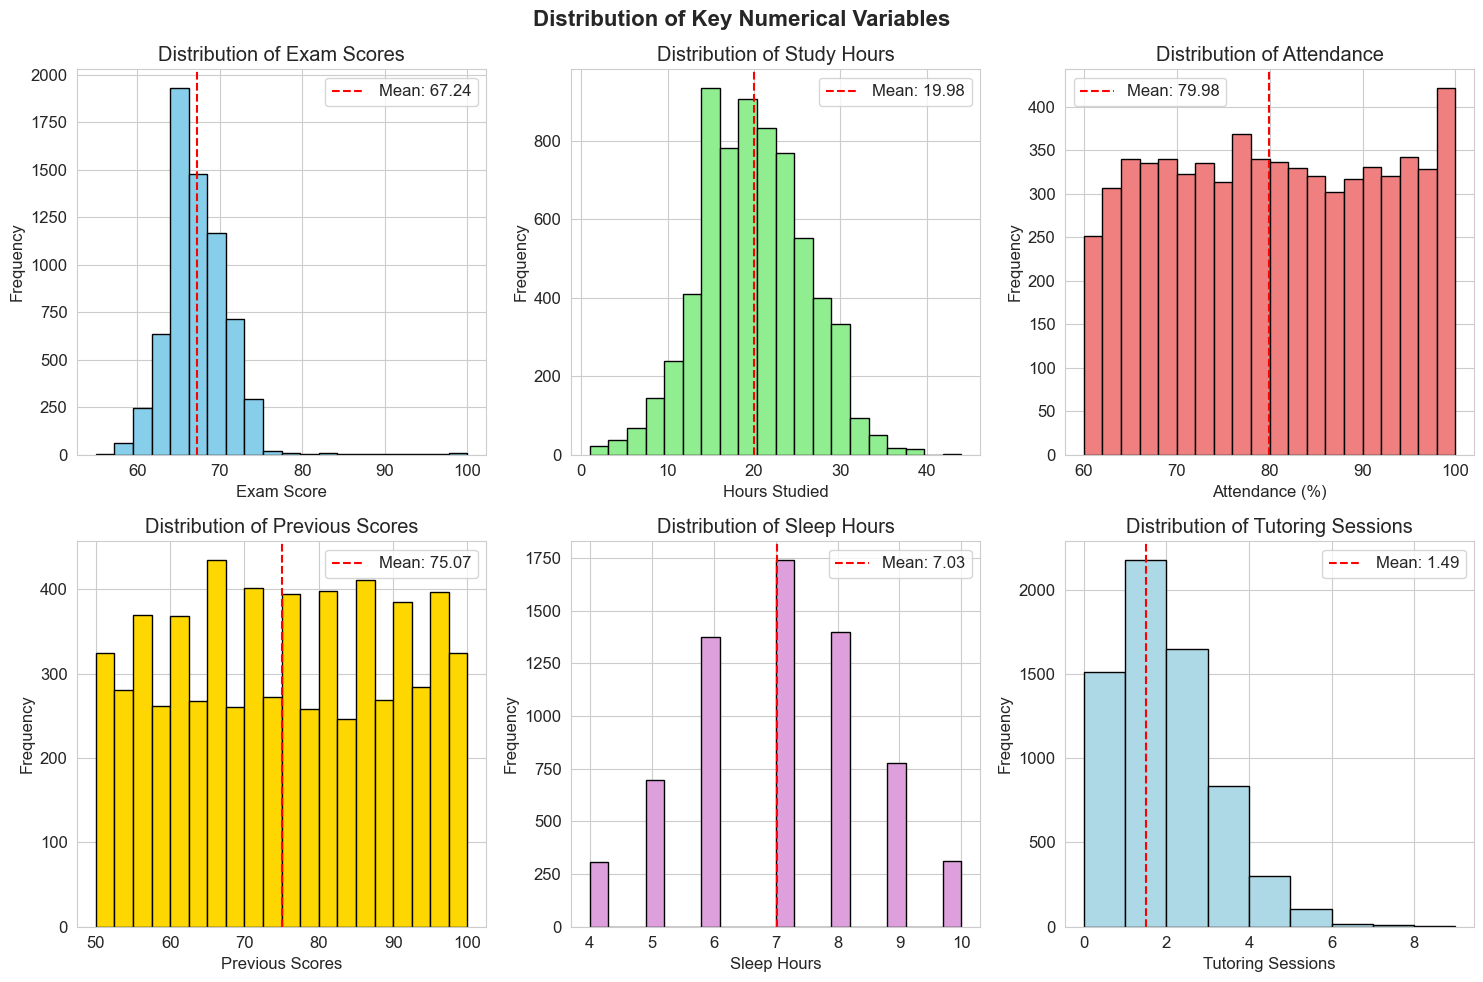

✓ Figure 1: Distribution plots displayed


In [18]:
# Cell 11: Data Visualization - Part 1 (Distributions)
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TASK 4: DATA VISUALIZATION")
print("="*60)

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Key Numerical Variables', fontsize=16, fontweight='bold')

# 1. Exam Score Distribution
axes[0,0].hist(df['Exam_Score'], bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Exam Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Exam Scores')
axes[0,0].axvline(df['Exam_Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["Exam_Score"].mean():.2f}')
axes[0,0].legend()

# 2. Hours Studied Distribution
axes[0,1].hist(df['Hours_Studied'], bins=20, color='lightgreen', edgecolor='black')
axes[0,1].set_xlabel('Hours Studied')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Study Hours')
axes[0,1].axvline(df['Hours_Studied'].mean(), color='red', linestyle='--', label=f'Mean: {df["Hours_Studied"].mean():.2f}')
axes[0,1].legend()

# 3. Attendance Distribution
axes[0,2].hist(df['Attendance'], bins=20, color='lightcoral', edgecolor='black')
axes[0,2].set_xlabel('Attendance (%)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Distribution of Attendance')
axes[0,2].axvline(df['Attendance'].mean(), color='red', linestyle='--', label=f'Mean: {df["Attendance"].mean():.2f}')
axes[0,2].legend()

# 4. Previous Scores Distribution
axes[1,0].hist(df['Previous_Scores'], bins=20, color='gold', edgecolor='black')
axes[1,0].set_xlabel('Previous Scores')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Previous Scores')
axes[1,0].axvline(df['Previous_Scores'].mean(), color='red', linestyle='--', label=f'Mean: {df["Previous_Scores"].mean():.2f}')
axes[1,0].legend()

# 5. Sleep Hours Distribution
axes[1,1].hist(df['Sleep_Hours'], bins=20, color='plum', edgecolor='black')
axes[1,1].set_xlabel('Sleep Hours')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Sleep Hours')
axes[1,1].axvline(df['Sleep_Hours'].mean(), color='red', linestyle='--', label=f'Mean: {df["Sleep_Hours"].mean():.2f}')
axes[1,1].legend()

# 6. Tutoring Sessions Distribution
axes[1,2].hist(df['Tutoring_Sessions'], bins=range(10), color='lightblue', edgecolor='black')
axes[1,2].set_xlabel('Tutoring Sessions')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('Distribution of Tutoring Sessions')
axes[1,2].axvline(df['Tutoring_Sessions'].mean(), color='red', linestyle='--', label=f'Mean: {df["Tutoring_Sessions"].mean():.2f}')
axes[1,2].legend()

plt.tight_layout()
plt.show()
print("✓ Figure 1: Distribution plots displayed")